# Synthetic Difference-in-Difference (SDID)

## 1. 환경 설정 및 데이터 준비

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm
import matplotlib.patches as mpatches

from synthdid.get_data import california_prop99
from synthdid.synthdid import Synthdid

In [2]:
plt.style.use('ggplot')

In [3]:
df = pd.read_csv('../data/matheus_data/smoking.csv')

In [4]:
df['treated'] = ((df['california'] == True) & (df['after_treatment'] == True)).astype(int)
california_id_check = df[df['california'] == True]['state'].unique()
print(f"California의 state ID는 다음과 같습니다: {california_id_check}")
df.head()

California의 state ID는 다음과 같습니다: [3]


,state,year,cigsale,lnincome,beer,age15to24,retprice,california,after_treatment,treated
0,1,1970,89.800003,NaN,NaN,0.178862,39.599998,False,False,0
1,1,1971,95.400002,NaN,NaN,0.179928,42.700001,False,False,0
2,1,1972,101.099998,9.498476,NaN,0.180994,42.299999,False,False,0
3,1,1973,102.900002,9.550107,NaN,0.182060,42.099998,False,False,0
4,1,1974,108.199997,9.537163,NaN,0.183126,43.099998,False,False,0


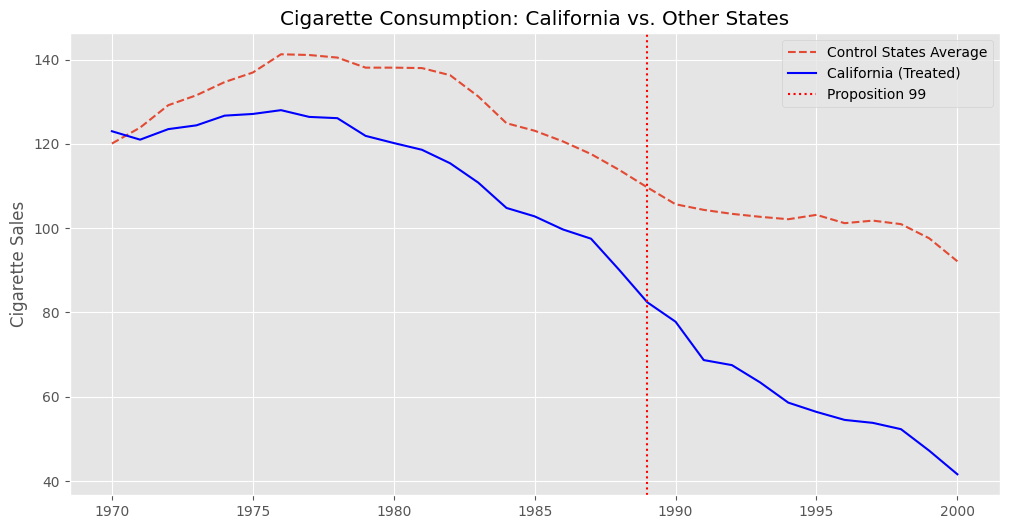

In [19]:
plt.figure(figsize=(12, 6))
california_df = df[df['california'] == True]
other_states_df = df[df['california'] == False]
plt.plot(other_states_df.groupby('year')['cigsale'].mean(), label='Control States Average', linestyle='--')
plt.plot(california_df['year'], california_df['cigsale'], label='California (Treated)', color='blue')
plt.axvline(x=1989, color='r', linestyle=':', label='Proposition 99')

plt.title('Cigarette Consumption: California vs. Other States')
plt.ylabel('Cigarette Sales')
plt.legend()
plt.show()

## 2. 핵심 SDID 분석 및 다른 방법론과 비교

SDID 분석의 타당성과 강점을 명확히 하기 위해, 인과추론의 대표적인 방법론인 **이중 차분법(DID)**과 **합성 대조법(SC)**을 함께 실행하여 결과를 비교 분석합니다. 구체적으로, 각 방법론이 정책 이전 기간의 추세를 얼마나 잘 모방하는지(평행추세 가정), 그리고 통제 그룹을 구성하기 위해 어떤 주(state)에 가중치를 부여하는지(Donor Pool)를 시각적으로 비교하여 왜 SDID가 이 데이터 분석에 가장 신뢰할 수 있는 방법론인지 입증하고자 합니다.

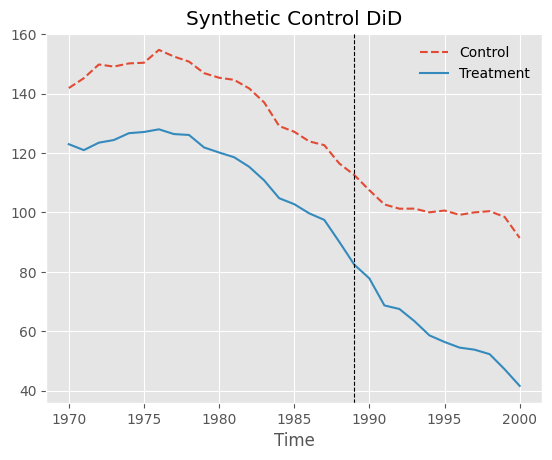

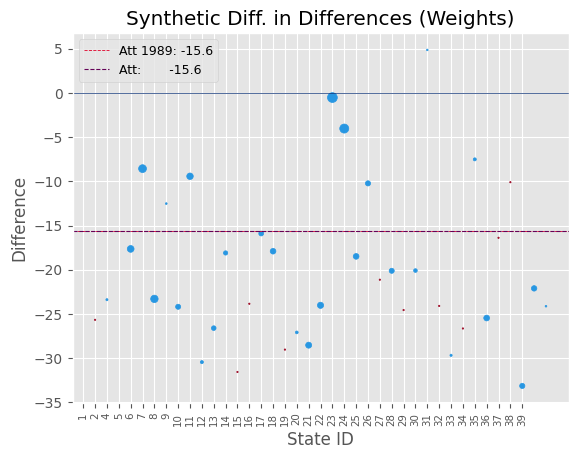

In [6]:
# SDID 결과 그래프
fit_model = Synthdid(df, "state", "year", "treated", "cigsale").fit().plot_outcomes(wtplot = False)
plt.title("Synthetic Control DiD")
plt.show()

# SDID 가중치 그래프
fit_model.plot_weights()
plt.title("Synthetic Diff. in Differences (Weights)")
plt.xlabel("State ID")
plt.show()


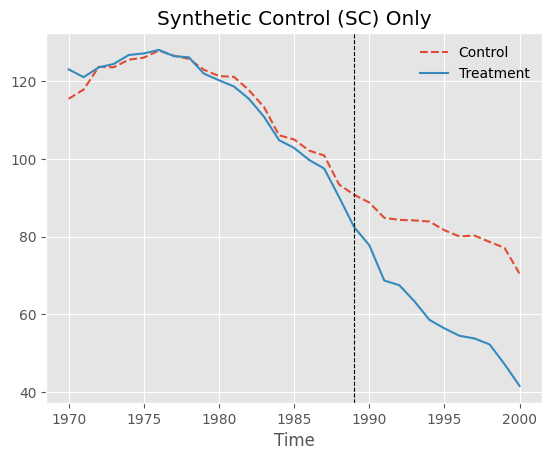

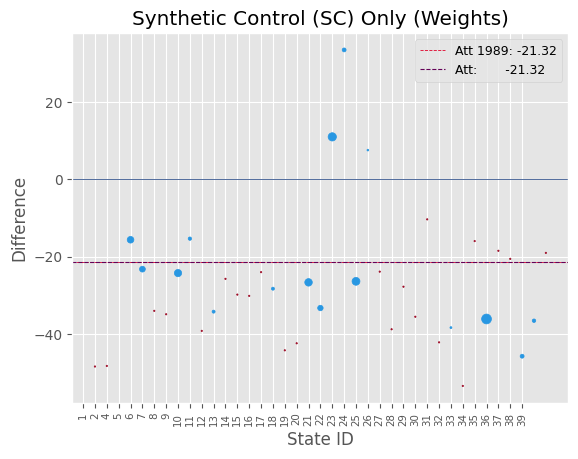

In [7]:
# 합성 대조군(SC) 결과와 비교
fit_sc = Synthdid(df, "state", "year", "treated", "cigsale").fit(synth=True, omega_intercept=False).plot_outcomes(wtplot = False)
plt.title("Synthetic Control (SC) Only")
plt.show()

# SC 가중치 그래프
fit_sc.plot_weights()
plt.title("Synthetic Control (SC) Only (Weights)")
plt.xlabel("State ID")
plt.show()

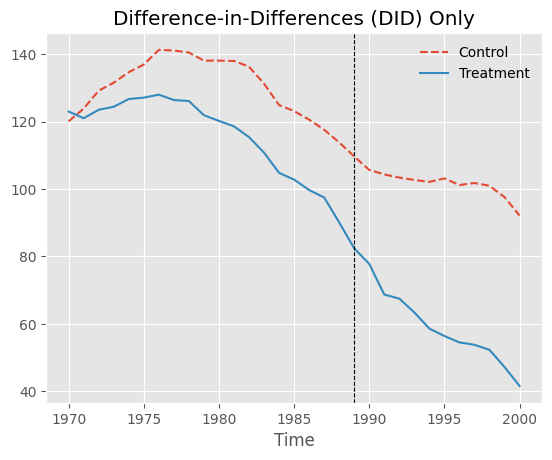

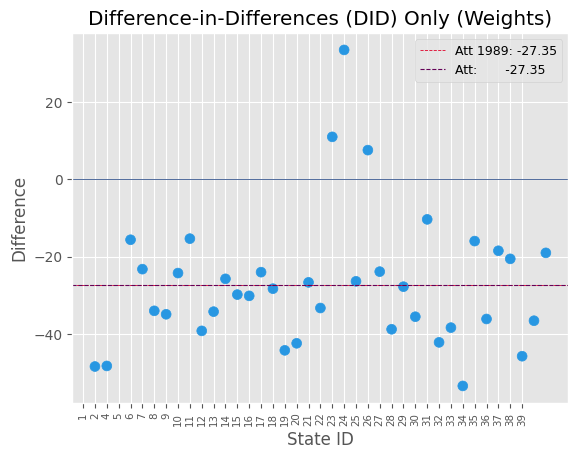

In [8]:
# 이중 차분법(DID) 결과와 비교
fit_did = Synthdid(df, "state", "year", "treated", "cigsale").fit(did=True).plot_outcomes(wtplot = False)
plt.title("Difference-in-Differences (DID) Only")
plt.show()

# DID 가중치 그래프
fit_did.plot_weights()
plt.title("Difference-in-Differences (DID) Only (Weights)")
plt.xlabel("State ID")
plt.show()

DID: 정책이 시행되기 전부터 처리군(California)과 통제군(Control Average)의 추세가 명백히 달라 평행추세 가정이 위배됨을 확인할 수 있습니다.
SC 및 SDID: 반면, SC와 SDID는 유닛 가중치(unit weights)를 통해 캘리포니아와 유사한 합성 대조군을 생성하여, 정책 이전 기간의 추세를 효과적으로 모방합니다. 이는 단순 DID 분석이 이 데이터에 부적합하며, 가중치 기반 방법론이 필수적임을 보여줍니다.

Note: DID는 모든 주에 동일한 가중치를 부여하는 반면, SC와 SDID는 캘리포니아와 유사한 특성을 가진 특정 '기부 주(donor states)'에 선택적으로 가중치를 부여하여 정교한 합성 대조군을 만들어냅니다.

## 3. 재현성 검증
- 원본 논문인 **Arkhangelsky et al. (2021)** ["Synthetic difference-in-differences"](https://www.aeaweb.org/articles?id=10.1257/aer.20190159)의 핵심 파라미터(Omega, Lambda)를 동일하게 재현했으며, AA 테스트를 통해 모델의 안정성을 검증했습니다.

In [9]:
# 단위 가중치(Omega) 확인
omega_weights = fit_model.weights['omega'][0]
all_unit_names = fit_model.Y_units[0]

num_control_units = fit_model.att_info['N0'][0]

control_unit_names = all_unit_names[:num_control_units]

omega_with_names = pd.Series(omega_weights, index=control_unit_names)
sorted_omega = omega_with_names.sort_values(ascending=False)

print("Omega (Unit Weights) by State (Top 10)")
print(sorted_omega.head(10))

# Nevada           0.124489
# New Hampshire    0.105048
# Connecticut      0.078287
# Delaware         0.070368
# Colorado         0.057513
# Illinois         0.053388
# Nebraska         0.047853
# Montana          0.045135
# Utah             0.041518
# New Mexico       0.040568

Omega (Unit Weights) by State (Top 10)
unit
21    0.124489
22    0.105048
5     0.078287
6     0.070368
4     0.057513
9     0.053388
20    0.047853
19    0.045135
34    0.041518
23    0.040568
dtype: float64


In [10]:
# 시간 가중치(Lambda) 확인
lambda_weights = fit_model.weights['lambda'][0]
all_time_periods = fit_model.Y_betas[0].columns
num_pre_periods = fit_model.att_info['T0'][0]
pre_treatment_periods = all_time_periods[:num_pre_periods]

lambda_by_year = pd.Series(lambda_weights, index=pre_treatment_periods)
sorted_lambda = lambda_by_year.sort_values(ascending=False)

print("Lambda (Time Weights) by Year (Top 5)")
print(sorted_lambda.head(5))

Lambda (Time Weights) by Year (Top 5)
time
1988    0.427076
1986    0.366471
1987    0.206453
1980    0.000000
1985    0.000000
dtype: float64


### AA 테스트 실행

--- AA Test Pre-treatment RMSE Calculation ---
AA Test Pre-treatment RMSE: 20.7107
--------------------------------------------

AA 테스트 ATT 결과 요약:
       ATT  Std. Err.         t    P>|t|
0 -2.92498   4.676653 -0.625443  0.53168


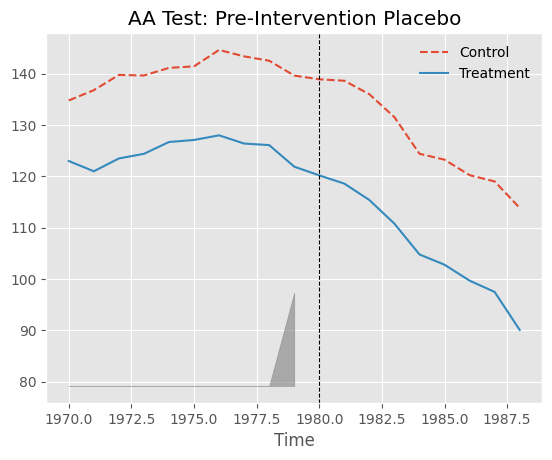

In [11]:
# AA 테스트 (시간축 플라시보 테스트)
print("### AA 테스트 실행")

# 1. AA 테스트를 위한 데이터 준비 (정책 이전 기간만 사용)
california_id = df[df['california'] == True]['state'].iloc[0]
df_aa = df[df['year'] <= 1988].copy()
# 1980-1988년을 가짜 처리 기간으로 설정
df_aa['treated_aa'] = ((df_aa['state'] == california_id) & (df_aa['year'] >= 1980)).astype(int)

# 2. AA 테스트 모델 적합
fit_model_aa = Synthdid(df_aa, "state", "year", "treated_aa", "cigsale").fit()

# 3. AA 테스트 기간의 RMSE 계산 
print("\n--- AA Test Pre-treatment RMSE Calculation ---")

# 3-1. 실제 값(Actual Outcome) 추출
actual_outcome = df_aa[df_aa['treated_aa'] == 1]['cigsale'].values

# 3-2. 반사실(Potential Outcome) 직접 계산
aa_omega_weights = fit_model_aa.weights['omega'][0]
control_states_aa = df_aa[df_aa['state'] != california_id]
control_wide_aa = control_states_aa.pivot(index='year', columns='state', values='cigsale')
aa_treatment_mask = (control_wide_aa.index >= 1980)
potential_outcome = control_wide_aa[aa_treatment_mask].dot(aa_omega_weights).values

# 3-3. RMSE 계산 및 출력
rmse_aa = np.sqrt(np.mean((actual_outcome - potential_outcome)**2))
print(f"AA Test Pre-treatment RMSE: {rmse_aa:.4f}")
print("--------------------------------------------\n")


# 4. 기존 AA 테스트 결과 출력
print("AA 테스트 ATT 결과 요약:")
fit_model_aa.vcov().summary()
print(fit_model_aa.summary2)

# 5. 기존 AA 테스트 그래프 시각화
fit_model_aa.plot_outcomes()
plt.title('AA Test: Pre-Intervention Placebo')
plt.show()

AA 테스트 결과, 정책 효과(ATT)는 -2.92로 0에 가까우며, 통계적으로 유의하지 않았습니다. 이는 본 모델이 정책 효과가 없었던 기간에 가짜 효과(false positive)를 생성하지 않음을 의미합니다.
예측 오차(RMSE=20.7)가 존재함에도 불구하고 통계적으로 유의한 편향(bias)이 나타나지 않았으므로, 분석 모델의 안정성이 검증되었습니다.

## 4. 모델 강건성 및 통계적 추론
이 섹션에서는 앞에서 추정한 정책 효과(ATT)가 통계적으로 유의미하며 강건한(robust) 결과인지 다각도로 검증합니다.
- 먼저, 각 모델별 ATT와 통계적 유의성을 표로 제시하고, Gap Plot을 통해 정책 효과가 시간에 따라 어떻게 변화하는지 시각적으로 분석합니다.
- 다음으로, **단위축 플라시보 테스트(in-space placebo test)**를 통해 실제 효과를 가짜 효과(placebo effect)들의 분포(히스토그램) 및 **시간적 추세(시계열 그래프)**와 비교하여 결과의 통계적 유의성을 판단합니다.
- 마지막으로, 정책 시행 전후의 예측 오차(MSPE) 비율을 플라시보 분포와 비교하여, 관찰된 정책 효과가 우연에 의한 결과일 가능성을 평가하고 분석의 강건성을 진단합니다.

In [12]:
# SDID 최종 추론
placebo_summary_sdid = fit_model.vcov(method='placebo')
placebo_summary_sdid.summary()
print("### 최종 추론 결과")
print("------------------------------------------------------------")
print("합성 차분 분석법 (SDID)")
print(placebo_summary_sdid.summary2)

# SC 최종 추론
placebo_summary_sc = fit_sc.vcov(method='placebo')
placebo_summary_sc.summary()
print("\n------------------------------------------------------------")
print("합성 대조법 (SC)")
print(placebo_summary_sc.summary2)

# DID 최종 추론
placebo_summary_did = fit_did.vcov(method='placebo')
placebo_summary_did.summary()
print("\n------------------------------------------------------------")
print("이중 차분법 (DID)")
print(placebo_summary_did.summary2)

### 최종 추론 결과
------------------------------------------------------------
합성 차분 분석법 (SDID)
        ATT  Std. Err.         t     P>|t|
0 -15.60383   8.993271 -1.735056  0.082731

------------------------------------------------------------
합성 대조법 (SC)
        ATT  Std. Err.         t     P>|t|
0 -21.32104   7.649162 -2.787369  0.005314

------------------------------------------------------------
이중 차분법 (DID)
        ATT  Std. Err.         t     P>|t|
0 -27.34911    9.80122 -2.790378  0.005265


### 효과 크기 시각화 (Gap Plot)

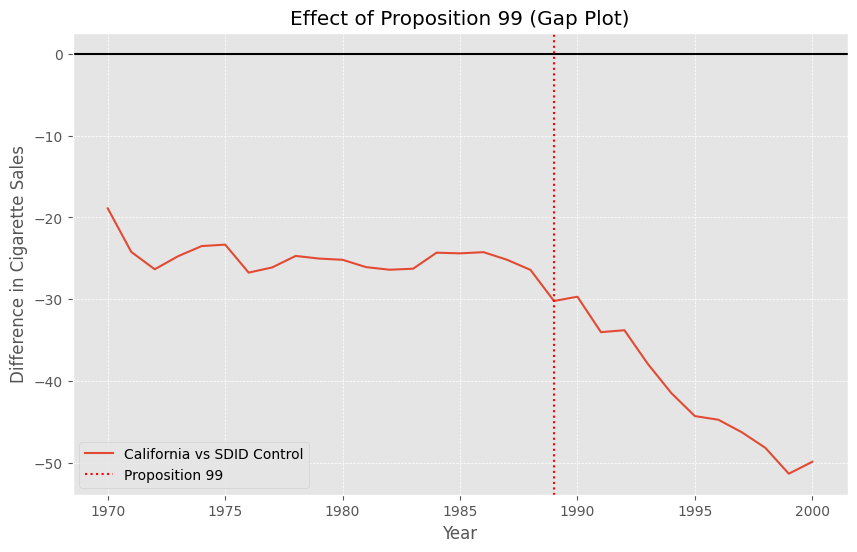

In [25]:
# SDID 모델의 예측값(가상 캘리포니아)을 사용해 캘리포니아(실제 처리군)의 Gap을 계산합니다.
california_id = df[df['california'] == True]['state'].iloc[0]
california_actual = df[df['state'] == california_id].set_index('year')['cigsale']
control_df_wide = df[df['state'] != california_id].pivot(index='year', columns='state', values='cigsale')
omega_series = pd.Series(fit_model.weights['omega'][0], index=control_df_wide.columns)
sdid_control = control_df_wide.dot(omega_series)

gap = california_actual - sdid_control

# Gap Plot 시각화
plt.figure(figsize=(10, 6))
plt.plot(gap.index, gap.values, label='California vs SDID Control')
plt.axhline(y=0, color='black', linestyle='-')
plt.axvline(x=1989, color='red', linestyle=':', label='Proposition 99')

plt.title('Effect of Proposition 99 (Gap Plot)')
plt.ylabel('Difference in Cigarette Sales')
plt.xlabel('Year')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

Gap Plot에서 정책 시행 이후 선이 0 아래로 크게 떨어지는 것은 Proposition 99 정책이 담배 판매량을 눈에 띄게 감소시켰음을 시각적으로 보여줍니다. 이 Gap 플롯은 정책 시행 이후 정책의 순수한 효과 크기가 시간에 따라 어떻게 변화하는지를 보여주는 그래프로, Y축은 실제 캘리포니아 판매량과 모델이 예측한 가상 판매량 간의 차이를 나타냅니다.

### 단위축 플라시보 테스트 (Placebo Distribution Histogram)

100%|██████████| 38/38 [00:23<00:00,  1.64it/s]


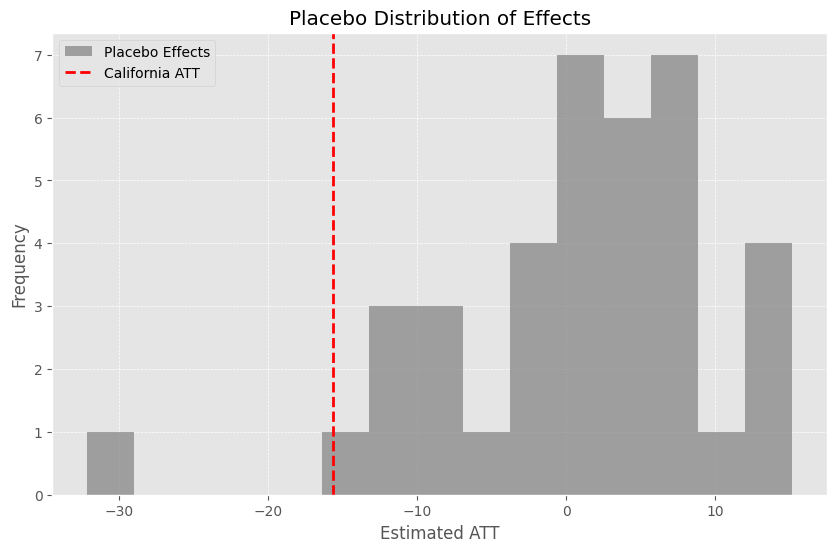

In [ ]:
# 플라시보 분포 시각화를 위한 계산
real_att = fit_model.att
control_states = df.loc[df['california'] == False, 'state'].unique()

placebo_atts = []

for state_id in tqdm(control_states): 
    df_placebo = df.copy()
    df_placebo['treated_placebo'] = 0
    df_placebo.loc[(df_placebo['state'] == state_id) & (df_placebo['year'] > 1988), 'treated_placebo'] = 1
    try:
        fit_placebo = Synthdid(df_placebo, "state", "year", "treated_placebo", "cigsale").fit()
        placebo_atts.append(fit_placebo.att)
    except Exception as e:
        continue

# 플라시보 분포 시각화
plt.figure(figsize=(10, 6))
plt.hist(placebo_atts, bins=15, color='gray', alpha=0.7, label='Placebo Effects')

# 실제 캘리포니아의 효과를 붉은색 수직선으로 표시
plt.axvline(x=real_att, color='red', linestyle='--', linewidth=2, label='California ATT')

plt.title("Placebo Distribution of Effects")
plt.xlabel("Estimated ATT")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

이는 캘리포니아의 실제 효과(붉은 선)가 0 근처에 밀집된 대부분의 플라시보 효과(회색 막대)의 주축에서 시각적으로 벗어나 있음을 보여줍니다. 캘리포니아의 효과는 분포의 왼쪽 꼬리 부분에 위치하여 상대적으로 드문 값임을 시사합니다.

### 플라시보 효과 추세 비교 (Placebo Trend Comparison)

100%|██████████| 38/38 [00:22<00:00,  1.66it/s]


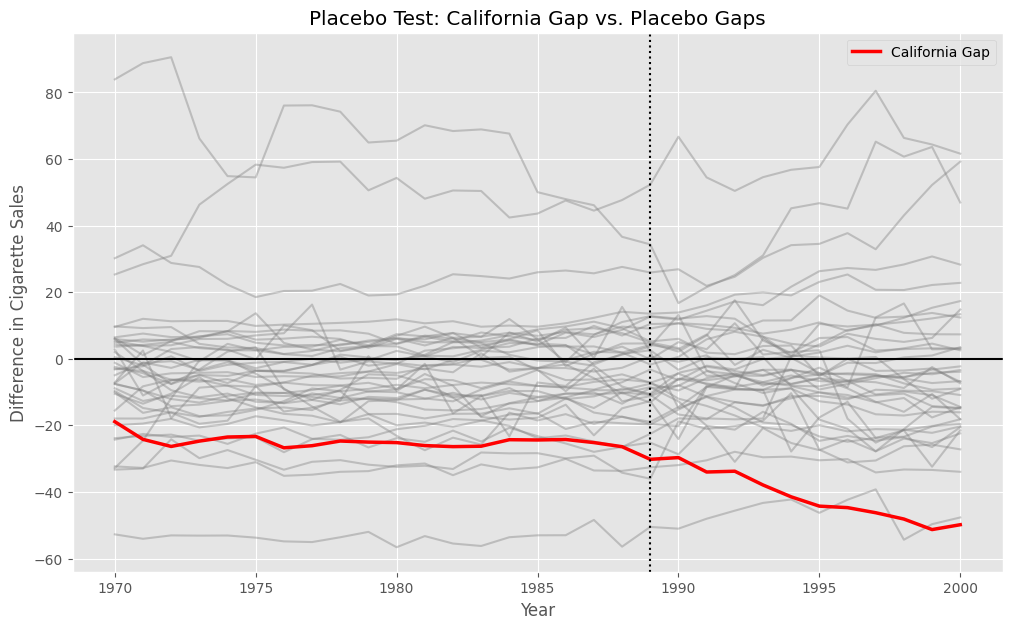

In [26]:
# 캘리포니아(실제 처리군)의 Gap을 먼저 계산합니다. (이전과 동일)
california_id = df[df['california'] == True]['state'].unique()[0]
california_actual = df[df['state'] == california_id].set_index('year')['cigsale']
control_df_wide = df[df['state'] != california_id].pivot(index='year', columns='state', values='cigsale')
sdid_weights_series = pd.Series(fit_model.weights['omega'][0], index=control_df_wide.columns)
sdid_control = control_df_wide.dot(sdid_weights_series)
california_gap = california_actual - sdid_control

# 각 통제 주에 대한 Placebo Gap을 다시 계산합니다.
placebo_gaps = []
all_states = df['state'].unique()
control_states = [s for s in all_states if s != california_id]

for state_id in tqdm(control_states):
    df_placebo = df.copy()
    df_placebo['treated_placebo'] = ((df_placebo['state'] == state_id) & (df_placebo['year'] > 1988)).astype(int)
    
    try:
        ## 플라시보 모델 적합
        fit_p = Synthdid(df_placebo, "state", "year", "treated_placebo", "cigsale").fit()

        ## 가짜 처리군의 실제 데이터
        actual = df[df['state'] == state_id].set_index('year')['cigsale']
        
        ## 현재 플라시보 처리군(state_id)을 모든 주로 통제군 데이터프레임을 구성합니다.
        control_states_for_this_run = [s for s in all_states if s != state_id]
        control_wide_p = df[df['state'].isin(control_states_for_this_run)].pivot(index='year', columns='state', values='cigsale')

        weights_series = pd.Series(fit_p.weights['omega'][0], index=control_wide_p.columns)
        
        # 가중 평균을 계산하여 가상 비교 집단 생성
        synthetic_control = control_wide_p.dot(weights_series)
        placebo_gaps.append(actual - synthetic_control)
        
    except Exception as e:
        continue

# 플라시보 추세선 시각화 
plt.figure(figsize=(12, 7))

# 모든 플라시보 gap 추세선을 회색으로 그리기
for gap_series in placebo_gaps:
    plt.plot(gap_series.index, gap_series.values, color='gray', alpha=0.4)

# 실제 캘리포니아의 gap 추세선을 붉은색으로 강조하여 그리기
plt.plot(california_gap.index, california_gap.values, color='red', linewidth=2.5, label='California Gap')

plt.axhline(y=0, color='black', linestyle='-')
plt.axvline(x=1989, color='black', linestyle=':')
plt.title('Placebo Test: California Gap vs. Placebo Gaps')
plt.ylabel('Difference in Cigarette Sales')
plt.xlabel('Year')
plt.legend()
plt.show()

정책 시행 후 캘리포니아의 담배 판매량 감소 효과(붉은색 선)는 다른 주들에서 나타난 우연에 의한 효과(회색 선들)들의 일반적인 추세에서 크게 벗어나 이례적으로 나타납니다. 이는 관찰된 효과의 패턴이 통계적으로 의미 있음을 보여줍니다.

### MSPE 비율을 통한 강건성 검증

SDID gaps (placebos): 100%|██████████| 38/38 [00:25<00:00,  1.51it/s]


[SDID gaps • uniform metric] CA ratio = 2.7929 | rank = 13/39 | p ≈ 0.3158


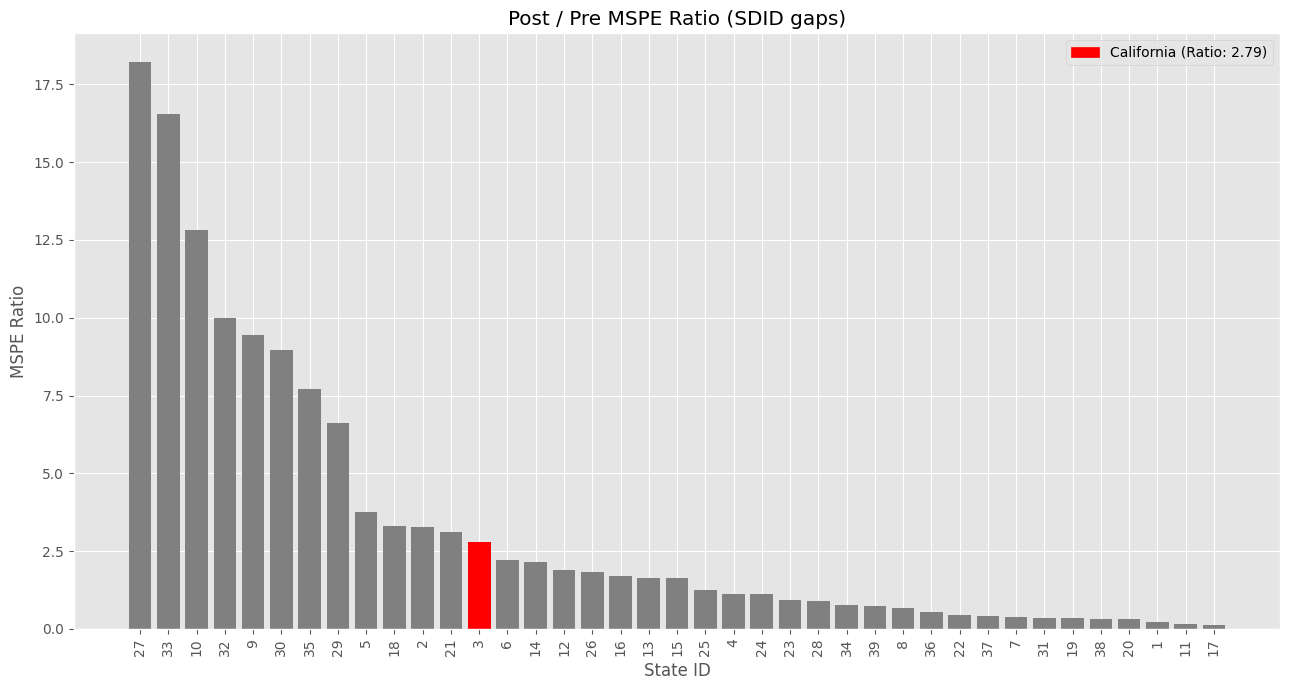

In [23]:
# california_id = df[df['california'] == True]['state'].unique()[0]
# california_actual = df[df['state'] == california_id].set_index('year')['cigsale']
# control_df_wide  = df[df['state'] != california_id].pivot(index='year', columns='state', values='cigsale')
# sdid_weights_series = pd.Series(fit_model.weights['omega'][0], index=control_df_wide.columns)
# sdid_control = control_df_wide.dot(sdid_weights_series)
# california_gap = california_actual - sdid_control

treatment_year = 1989 
california_gap = california_gap.sort_index()

# 1) SDID로 모든 주(placebo) 갭 만들기
#    - 각 주를 treated로 두고, donors는 "그 주 제외, 나머지 전부"(CA 포함)
gaps = {int(california_id): california_gap.copy()}
all_states = sorted(df['state'].unique().tolist())

for sid in tqdm([s for s in all_states if s != california_id], desc="SDID gaps (placebos)"):
    try:
        df_p = df.copy()
        df_p['treated_placebo'] = ((df_p['state'] == sid) & (df_p['year'] >= treatment_year)).astype(int)

        fit_p = Synthdid(df_p, "state", "year", "treated_placebo", "cigsale").fit()

        actual_p = (
            df_p.loc[df_p['state'] == sid, ['year','cigsale']]
                .sort_values('year').set_index('year')['cigsale']
        )
        donors_wide_p = (
            df_p.loc[df_p['state'] != sid, ['year','state','cigsale']]
                .pivot(index='year', columns='state', values='cigsale')
                .sort_index()
        )

        w_p = pd.Series(fit_p.weights['omega'][0], index=donors_wide_p.columns)
        synth_p = donors_wide_p.dot(w_p)

        yrs = actual_p.index.intersection(synth_p.index)
        gaps[int(sid)] = (actual_p.loc[yrs] - synth_p.loc[yrs]).sort_index()

    except Exception as e:
        # 문제가 있는 유닛은 건너뜀 (필요하면 print로 확인)
        continue

# 2) 모든 주 공통 연도만 사용해 하나의 DF로 결합
years_common_all = None
for g in gaps.values():
    years_common_all = g.index if years_common_all is None else years_common_all.intersection(g.index)

gaps_df = pd.DataFrame({k: v.loc[years_common_all] for k, v in gaps.items()}).sort_index()


# 3)  MSPE 비율 + p-value
def get_pre_post_mspe(gap_series, t0):
    pre  = gap_series[gap_series.index <  t0]
    post = gap_series[gap_series.index >= t0]
    return float(np.mean(pre**2)), float(np.mean(post**2))

mspe_df = gaps_df.apply(
    lambda col: pd.Series(get_pre_post_mspe(col, treatment_year),
                          index=['pre_treatment_mspe','post_treatment_mspe']),
    axis=0
).T

mspe_df['mspe_ratio'] = mspe_df['post_treatment_mspe'] / mspe_df['pre_treatment_mspe']
mspe_sorted = mspe_df.sort_values(by='mspe_ratio', ascending=False).reset_index().rename(columns={'index':'State'})

ca_id = int(california_id)
ca_ratio = float(mspe_df.loc[ca_id, 'mspe_ratio'])

mspe_df_excl_ca = mspe_df.drop(index=ca_id)  
p_value = (mspe_df_excl_ca['mspe_ratio'] >= ca_ratio).mean()  # one-sided

rank_ge = int((mspe_df_excl_ca['mspe_ratio'] >= ca_ratio).sum()) + 1  # 표기용 순위(=CA 포함 표기)
print(f"[SDID gaps • uniform metric] CA ratio = {ca_ratio:.4f} | rank = {rank_ge}/{mspe_df_excl_ca.shape[0]+1} | p ≈ {p_value:.4f}")


# 4) 그래프 
plt.figure(figsize=(13,7))
colors = ['red' if int(s)==ca_id else 'gray' for s in mspe_sorted['State']]
plt.bar(mspe_sorted['State'].astype(str), mspe_sorted['mspe_ratio'], color=colors)
plt.legend(handles=[mpatches.Patch(color='red', label=f'California (Ratio: {ca_ratio:.2f})')])
plt.xticks(rotation=90)
plt.title('Post / Pre MSPE Ratio (SDID gaps)')
plt.ylabel('MSPE Ratio'); plt.xlabel('State ID')
plt.tight_layout(); plt.show()


이 그래프는 캘리포니아(ID 3, 붉은색)의 정책 시행 전후 MSPE 비율이 다른 플라시보 주들(회색)과 비교하여 어느 위치에 있는지를 보여줍니다. 캘리포니아의 비율(2.79)은 전체 39개 주 중 13번째로, 이는 다른 주들에 비해 특별히 높거나 극단적인 값이 아님을 의미합니다. 따라서 이 플라시보 테스트 결과는 캘리포니아의 정책 효과가 통계적으로 강건하지 않을 수 있음을 시사합니다.

### 질문이나 의견을 남겨주세요.
<script src="https://utteranc.es/client.js"
        repo="CausalInferenceLab/awesome-causal-inference-python"
        issue-term="pathname"
        theme="github-light"
        crossorigin="anonymous"
        async>
</script>